In [1]:
import os
import warnings

warnings.filterwarnings("ignore")
import joblib
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    r2_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    GroupKFold,
    LeaveOneGroupOut,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import KBinsDiscretizer, StandardScaler
from tools import load_data

# Logistic Regression (LR)

In [2]:
X, T, F, A, P = load_data([ps for ps in range(1, 16)], z_score_norm=None)
X = X.reshape(X.shape[0], X.shape[1] * X.shape[1])

load: ['P01', 'P02', 'P03', 'P04', 'P05', 'P06', 'P07', 'P08', 'P09', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15']


$$\mathbf{X} \rightarrow \mathrm{EIT}$$
$$A \rightarrow \mathrm{Angle}$$
$$T \rightarrow \mathrm{Torque}$$
$$F \rightarrow \mathrm{Force}$$

In [3]:
def indices_with_tolerance(arr, target, tol):
    """
    A ... angle/position or Force or Torque
    target ... target angle
    tol ... +/- tolerance
    """
    arr = np.asarray(arr)
    detected = np.where(np.abs(arr - target) <= tol)[0]
    print(f"Found {len(detected):,} for position {target} and a tolerance of {tol}.")
    return detected

In [4]:
param_grid = [
    {
        "LR__penalty": ["l2"],
        "LR__C": [0.01, 0.1, 1, 10, 100],
        "LR__solver": ["lbfgs", "newton-cg"],
        "LR__class_weight": [None, "balanced"],
    },
    {
        "LR__penalty": ["l1"],
        "LR__C": [0.01, 0.1, 1, 10],
        "LR__solver": ["liblinear", "saga"],
        "LR__class_weight": [None, "balanced"],
    },
    {
        "LR__penalty": ["elasticnet"],
        "LR__C": [0.01, 0.1, 1, 10],
        "LR__solver": ["saga"],
        "LR__l1_ratio": [0.1, 0.5, 0.9],
        "LR__class_weight": ["balanced"],
    },
]

## Mapping: $\mathbf{X} \rightarrow A|_{\mathrm{targets}}$

In [5]:
p1s = indices_with_tolerance(A, 25, tol=1)  # Adjustment place
p2s = indices_with_tolerance(A, 50, tol=1)  # Adjustment place
p3s = indices_with_tolerance(A, 75, tol=1)  # Adjustment place
# define targets
targets = np.concatenate([p1s, p2s, p3s])
y_label = [r"25$\pm$1°", r"50$\pm$1°", r"75$\pm$1°"]  # Adjustment place
np.random.shuffle(targets)

Found 1,049 for position 25 and a tolerance of 1.
Found 1,041 for position 50 and a tolerance of 1.
Found 1,052 for position 75 and a tolerance of 1.


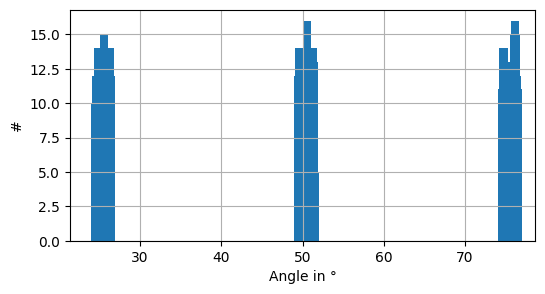

In [6]:
plt.figure(figsize=(6, 3))
plt.hist(A[targets], bins=len(targets), align="mid", width=1)  # Adjustment place
plt.grid()
plt.ylabel("#")
plt.xlabel("Angle in °")  # Adjustment place
plt.show()

In [7]:
y = A[targets]  # A -> Angle # Adjustment place
EIT = X[targets]
Pwise = P[targets]

y_cont = y.reshape(-1, 1)
binning = KBinsDiscretizer(
    n_bins=3,
    encode="ordinal",
    strategy="quantile",
    quantile_method="averaged_inverted_cdf",
)
y = binning.fit_transform(y_cont).ravel()

_Train/Valid_

In [8]:
params_path = "params/TrainValid_A_LR.pkl"  # Adjustment place

pipe = Pipeline(
    [("scaler", StandardScaler()), ("LR", LogisticRegression())]
)  # Adjustment place

if os.path.exists(params_path):
    print("Loaded params")
    best_params_ = joblib.load(params_path)
else:
    grid = GridSearchCV(
        pipe, param_grid, scoring="accuracy", cv=5, n_jobs=80, verbose=1
    )
    grid.fit(EIT, y)
    best_params_ = {k.replace("LR__", ""): v for k, v in grid.best_params_.items()}
    joblib.dump(best_params_, params_path)
    print("Beste CV-Accuracy:", grid.best_score_)

print("beste parameter:", best_params_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Beste CV-Accuracy: 0.7603510779419359
beste parameter: {'C': 100, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'newton-cg'}


In [9]:
best_model = LogisticRegression(**best_params_)  # Adjustment place

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []
cmy_pred = []
cmy_true = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(EIT, y), 1):
    X_train, X_valid = EIT[train_idx], EIT[valid_idx]
    y_train, y_valid = y[train_idx], y[valid_idx]

    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_valid)

    cmy_pred.append(y_pred)
    cmy_true.append(y_valid)

    acc = balanced_accuracy_score(y_valid, y_pred)
    scores.append(acc)

    print(f"Fold {fold} Balanced Accuracy: {acc:.4f}")

cmy_pred = np.concatenate(cmy_pred)
cmy_true = np.concatenate(cmy_true)

print("\nMean Balanced Accuracy:", np.mean(scores))
print("Std Balanced Accuracy:", np.std(scores))

print("\naccuracy_score:", accuracy_score(cmy_true, cmy_pred))
print("balanced_accuracy_score:", balanced_accuracy_score(cmy_true, cmy_pred))
print("r2_score:", r2_score(cmy_true, cmy_pred))

Fold 1 Balanced Accuracy: 0.5533
Fold 2 Balanced Accuracy: 0.5487
Fold 3 Balanced Accuracy: 0.5524
Fold 4 Balanced Accuracy: 0.5843
Fold 5 Balanced Accuracy: 0.5493

Mean Balanced Accuracy: 0.5576015797068429
Std Balanced Accuracy: 0.0134855124017863

accuracy_score: 0.5576066199872692
balanced_accuracy_score: 0.5575721010715214
r2_score: -0.07159920814147958



Classification Report:
              precision    recall  f1-score   support

         0.0       0.59      0.64      0.61      1047
         1.0       0.47      0.37      0.41      1047
         2.0       0.59      0.67      0.63      1048

    accuracy                           0.56      3142
   macro avg       0.55      0.56      0.55      3142
weighted avg       0.55      0.56      0.55      3142



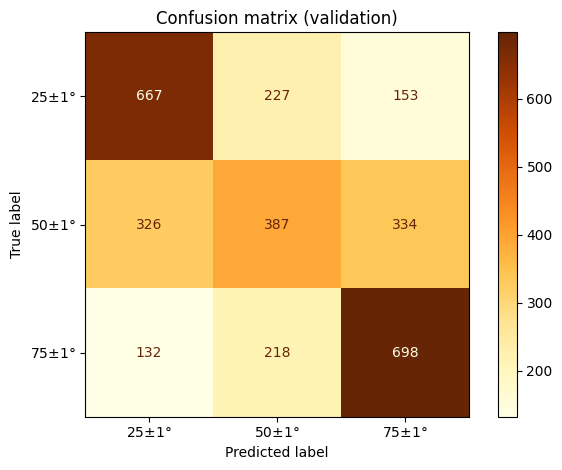

In [10]:
cm = confusion_matrix(cmy_true, cmy_pred)
print("\nClassification Report:")
print(classification_report(cmy_true, cmy_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_label)
disp.plot(cmap="YlOrBr", values_format="d")
plt.title("Confusion matrix (validation)")
plt.tight_layout()
plt.savefig("imgs/TrainValid_A_LR.pdf")  # Adjustment place
plt.show()

_Train/Test - Patient split_

In [11]:
params_path = "params/TrainTest_A_LR.pkl"  # Adjustment place

pipe = Pipeline(
    [("scaler", StandardScaler()), ("LR", LogisticRegression())]
)  # Adjustment place
cv = GroupKFold(n_splits=5)

if os.path.exists(params_path):
    print("Loaded params")
    best_params_ = joblib.load(params_path)
else:
    grid = GridSearchCV(
        pipe, param_grid, scoring="accuracy", cv=cv, n_jobs=80, verbose=1, refit=True
    )
    grid.fit(EIT, y, groups=Pwise)
    best_params_ = {k.replace("LR__", ""): v for k, v in grid.best_params_.items()}
    joblib.dump(best_params_, params_path)
    print("Best CV-Accuracy:", grid.best_score_)

print("Best parameter:", best_params_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best CV-Accuracy: 0.37768454167772797
Best parameter: {'C': 0.1, 'class_weight': None, 'penalty': 'l2', 'solver': 'lbfgs'}


In [12]:
best_model = LogisticRegression(**best_params_)  # Adjustment place

cv = GroupKFold(n_splits=5)
scores = []

cmy_pred = []
cmy_true = []
for fold, (train_idx, test_idx) in enumerate(cv.split(EIT, y, groups=Pwise), 1):
    X_train, X_test = EIT[train_idx], EIT[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)
    cmy_pred.append(y_pred)
    cmy_true.append(y_test)
    acc = balanced_accuracy_score(y_test, y_pred)
    scores.append(acc)
    print(f"Fold {fold} Accuracy: {acc:.4f}")

cmy_pred = np.concatenate(cmy_pred)
cmy_true = np.concatenate(cmy_true)

print("\nMean Accuracy:", np.mean(scores))
print("Std Accuracy:", np.std(scores))
print("\naccuracy_score", accuracy_score(cmy_true, cmy_pred))
print("balanced_accuracy_score", balanced_accuracy_score(cmy_true, cmy_pred))

Fold 1 Accuracy: 0.3698
Fold 2 Accuracy: 0.3480
Fold 3 Accuracy: 0.3343
Fold 4 Accuracy: 0.3967
Fold 5 Accuracy: 0.3156

Mean Accuracy: 0.3528727483250242
Std Accuracy: 0.028173401238030565

accuracy_score 0.354551241247613
balanced_accuracy_score 0.3545064536747426



Classification Report:
              precision    recall  f1-score   support

         0.0       0.34      0.50      0.41      1047
         1.0       0.31      0.07      0.11      1047
         2.0       0.38      0.50      0.43      1048

    accuracy                           0.35      3142
   macro avg       0.34      0.35      0.31      3142
weighted avg       0.34      0.35      0.31      3142



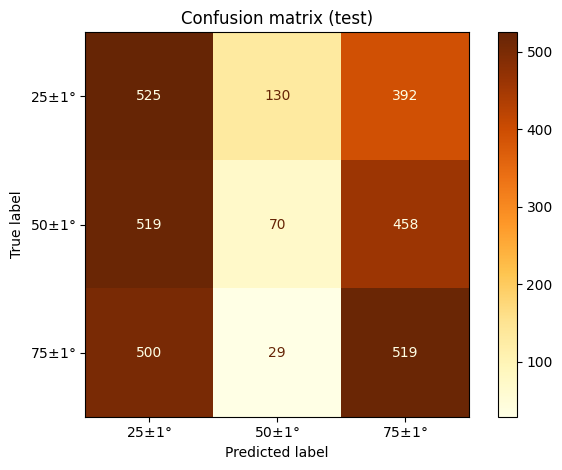

In [13]:
cm = confusion_matrix(cmy_true, cmy_pred)
print("\nClassification Report:")
print(classification_report(cmy_true, cmy_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_label)
disp.plot(cmap="YlOrBr", values_format="d")
plt.title("Confusion matrix (test)")
plt.tight_layout()
plt.savefig("imgs/TrainTest_A_LR.pdf")  # Adjustment place
plt.show()

## Mapping: $\mathbf{X} \rightarrow T|_{\mathrm{targets}}$

In [14]:
p1s = indices_with_tolerance(T, 30, tol=1)  # Adjustment place
p2s = indices_with_tolerance(T, 50, tol=1)  # Adjustment place
p3s = indices_with_tolerance(T, 70, tol=1)  # Adjustment place
# define targets
targets = np.concatenate([p1s, p2s, p3s])
y_label = [r"50$\pm$20Nm", r"125$\pm$20Nm", r"200$\pm$20Nm"]  # Adjustment place
np.random.shuffle(targets)

Found 2,523 for position 30 and a tolerance of 1.
Found 1,953 for position 50 and a tolerance of 1.
Found 1,249 for position 70 and a tolerance of 1.


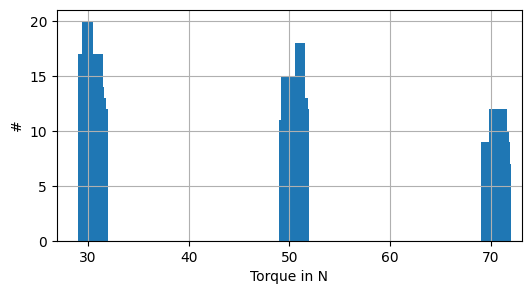

In [15]:
plt.figure(figsize=(6, 3))
plt.hist(T[targets], bins=len(targets), align="mid", width=1)  # Adjustment place
plt.grid()
plt.ylabel("#")
plt.xlabel("Torque in N")  # Adjustment place
plt.show()

In [16]:
y = T[targets]  # T -> Torque # Adjustment place
EIT = X[targets]
Pwise = P[targets]

y_cont = y.reshape(-1, 1)
binning = KBinsDiscretizer(
    n_bins=3,
    encode="ordinal",
    strategy="quantile",
    quantile_method="averaged_inverted_cdf",
)
y = binning.fit_transform(y_cont).ravel()

_Train/Valid_

In [17]:
params_path = "params/TrainValid_T_LR.pkl"  # Adjustment place

pipe = Pipeline(
    [("scaler", StandardScaler()), ("LR", LogisticRegression())]
)  # Adjustment place

if os.path.exists(params_path):
    print("Loaded params")
    best_params_ = joblib.load(params_path)
else:
    grid = GridSearchCV(
        pipe, param_grid, scoring="accuracy", cv=5, n_jobs=80, verbose=1
    )
    grid.fit(EIT, y)
    best_params_ = {k.replace("LR__", ""): v for k, v in grid.best_params_.items()}
    joblib.dump(best_params_, params_path)
    print("Beste CV-Accuracy:", grid.best_score_)

print("beste parameter:", best_params_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Beste CV-Accuracy: 0.6595633187772926
beste parameter: {'C': 100, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'newton-cg'}


In [18]:
best_model = LogisticRegression(**best_params_)  # Adjustment place

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []
cmy_pred = []
cmy_true = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(EIT, y), 1):
    X_train, X_valid = EIT[train_idx], EIT[valid_idx]
    y_train, y_valid = y[train_idx], y[valid_idx]

    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_valid)

    cmy_pred.append(y_pred)
    cmy_true.append(y_valid)

    acc = balanced_accuracy_score(y_valid, y_pred)
    scores.append(acc)

    print(f"Fold {fold} Balanced Accuracy: {acc:.4f}")

cmy_pred = np.concatenate(cmy_pred)
cmy_true = np.concatenate(cmy_true)

print("\nMean Balanced Accuracy:", np.mean(scores))
print("Std Balanced Accuracy:", np.std(scores))

print("\naccuracy_score:", accuracy_score(cmy_true, cmy_pred))
print("balanced_accuracy_score:", balanced_accuracy_score(cmy_true, cmy_pred))
print("r2_score:", r2_score(cmy_true, cmy_pred))

Fold 1 Balanced Accuracy: 0.6051
Fold 2 Balanced Accuracy: 0.6103
Fold 3 Balanced Accuracy: 0.5939
Fold 4 Balanced Accuracy: 0.6158
Fold 5 Balanced Accuracy: 0.6184

Mean Balanced Accuracy: 0.6087186745635853
Std Balanced Accuracy: 0.008714284077254284

accuracy_score: 0.6087336244541485
balanced_accuracy_score: 0.6087282316761349
r2_score: 0.11605969232380053



Classification Report:
              precision    recall  f1-score   support

         0.0       0.63      0.72      0.67      1908
         1.0       0.51      0.46      0.49      1908
         2.0       0.67      0.64      0.66      1909

    accuracy                           0.61      5725
   macro avg       0.61      0.61      0.61      5725
weighted avg       0.61      0.61      0.61      5725



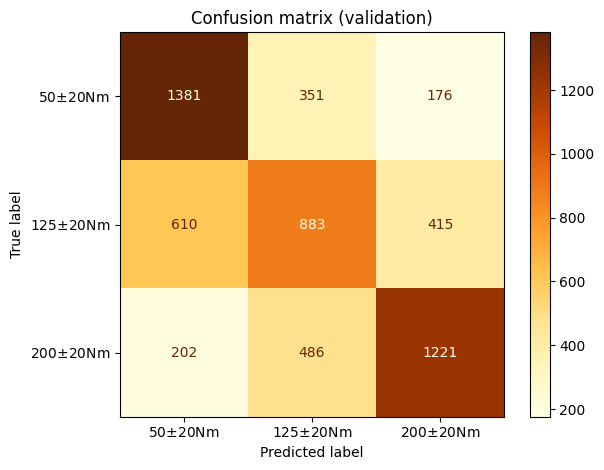

In [19]:
cm = confusion_matrix(cmy_true, cmy_pred)
print("\nClassification Report:")
print(classification_report(cmy_true, cmy_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_label)
disp.plot(cmap="YlOrBr", values_format="d")
plt.title("Confusion matrix (validation)")
plt.tight_layout()
plt.savefig("imgs/TrainValid_T_LR.pdf")  # Adjustment place
plt.show()

_Train/Test - Patient split_

In [20]:
params_path = "params/TrainTest_T_LR.pkl"  # Adjustment place

pipe = Pipeline(
    [("scaler", StandardScaler()), ("LR", LogisticRegression())]
)  # Adjustment place
cv = GroupKFold(n_splits=5)

if os.path.exists(params_path):
    print("Loaded params")
    best_params_ = joblib.load(params_path)
else:
    grid = GridSearchCV(
        pipe, param_grid, scoring="accuracy", cv=cv, n_jobs=80, verbose=1, refit=True
    )
    grid.fit(EIT, y, groups=Pwise)
    best_params_ = {k.replace("LR__", ""): v for k, v in grid.best_params_.items()}
    joblib.dump(best_params_, params_path)
    print("Best CV-Accuracy:", grid.best_score_)

print("Best parameter:", best_params_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best CV-Accuracy: 0.3788751665779444
Best parameter: {'C': 0.1, 'class_weight': None, 'penalty': 'l1', 'solver': 'saga'}


In [21]:
best_model = LogisticRegression(**best_params_)  # Adjustment place

cv = GroupKFold(n_splits=5)
scores = []

cmy_pred = []
cmy_true = []
for fold, (train_idx, test_idx) in enumerate(cv.split(EIT, y, groups=Pwise), 1):
    X_train, X_test = EIT[train_idx], EIT[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)
    cmy_pred.append(y_pred)
    cmy_true.append(y_test)
    acc = balanced_accuracy_score(y_test, y_pred)
    scores.append(acc)
    print(f"Fold {fold} Accuracy: {acc:.4f}")

cmy_pred = np.concatenate(cmy_pred)
cmy_true = np.concatenate(cmy_true)

print("\nMean Accuracy:", np.mean(scores))
print("Std Accuracy:", np.std(scores))
print("\naccuracy_score", accuracy_score(cmy_true, cmy_pred))
print("balanced_accuracy_score", balanced_accuracy_score(cmy_true, cmy_pred))

Fold 1 Accuracy: 0.2965
Fold 2 Accuracy: 0.3570
Fold 3 Accuracy: 0.3599
Fold 4 Accuracy: 0.3816
Fold 5 Accuracy: 0.3553

Mean Accuracy: 0.3500474296178398
Std Accuracy: 0.02841723444594931

accuracy_score 0.36087336244541485
balanced_accuracy_score 0.3608518478251718



Classification Report:
              precision    recall  f1-score   support

         0.0       0.36      0.33      0.34      1908
         1.0       0.36      0.27      0.31      1908
         2.0       0.37      0.48      0.42      1909

    accuracy                           0.36      5725
   macro avg       0.36      0.36      0.36      5725
weighted avg       0.36      0.36      0.36      5725



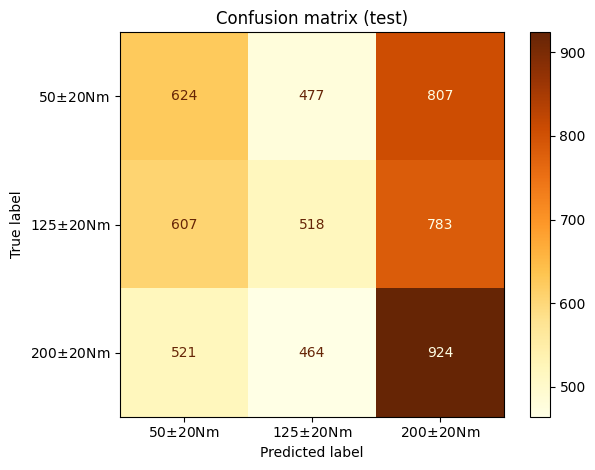

In [22]:
cm = confusion_matrix(cmy_true, cmy_pred)
print("\nClassification Report:")
print(classification_report(cmy_true, cmy_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_label)
disp.plot(cmap="YlOrBr", values_format="d")
plt.title("Confusion matrix (test)")
plt.tight_layout()
plt.savefig("imgs/TrainTest_T_LR.pdf")  # Adjustment place
plt.show()

## Mapping: $\mathbf{X} \rightarrow F|_{\mathrm{targets}}$

In [23]:
p1s = indices_with_tolerance(F, 50, tol=2)  # Adjustment place
p2s = indices_with_tolerance(F, 125, tol=2)  # Adjustment place
p3s = indices_with_tolerance(F, 200, tol=2)  # Adjustment place
# define targets
targets = np.concatenate([p1s, p2s, p3s])
y_label = [r"25$\pm$N", r"100$\pm$N", r"175$\pm$N"]  # Adjustment place
np.random.shuffle(targets)

Found 1,208 for position 50 and a tolerance of 2.
Found 1,545 for position 125 and a tolerance of 2.
Found 901 for position 200 and a tolerance of 2.


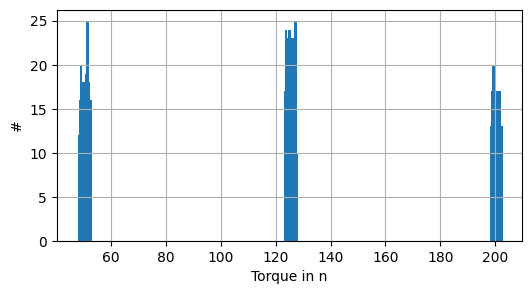

In [24]:
plt.figure(figsize=(6, 3))
plt.hist(F[targets], bins=len(targets), align="mid", width=1)  # Adjustment place
plt.grid()
plt.ylabel("#")
plt.xlabel("Torque in n")
plt.show()

In [25]:
y = F[targets]  # F -> Force # Adjustment place
EIT = X[targets]
Pwise = P[targets]

y_cont = y.reshape(-1, 1)
binning = KBinsDiscretizer(
    n_bins=3,
    encode="ordinal",
    strategy="quantile",
    quantile_method="averaged_inverted_cdf",
)
y = binning.fit_transform(y_cont).ravel()

_Train/Valid_

In [26]:
params_path = "params/TrainValid_F_LR.pkl"  # Adjustment place

pipe = Pipeline(
    [("scaler", StandardScaler()), ("LR", LogisticRegression())]
)  # Adjustment place

if os.path.exists(params_path):
    print("Loaded params")
    best_params_ = joblib.load(params_path)
else:
    grid = GridSearchCV(
        pipe, param_grid, scoring="accuracy", cv=5, n_jobs=80, verbose=1
    )
    grid.fit(EIT, y)
    best_params_ = {k.replace("LR__", ""): v for k, v in grid.best_params_.items()}
    joblib.dump(best_params_, params_path)
    print("Beste CV-Accuracy:", grid.best_score_)

print("beste parameter:", best_params_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Beste CV-Accuracy: 0.7334418979442685
beste parameter: {'C': 100, 'class_weight': None, 'penalty': 'l2', 'solver': 'newton-cg'}


In [27]:
best_model = LogisticRegression(**best_params_)  # Adjustment place

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []
cmy_pred = []
cmy_true = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(EIT, y), 1):
    X_train, X_valid = EIT[train_idx], EIT[valid_idx]
    y_train, y_valid = y[train_idx], y[valid_idx]

    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_valid)

    cmy_pred.append(y_pred)
    cmy_true.append(y_valid)

    acc = balanced_accuracy_score(y_valid, y_pred)
    scores.append(acc)

    print(f"Fold {fold} Balanced Accuracy: {acc:.4f}")

cmy_pred = np.concatenate(cmy_pred)
cmy_true = np.concatenate(cmy_true)

print("\nMean Balanced Accuracy:", np.mean(scores))
print("Std Balanced Accuracy:", np.std(scores))

print("\naccuracy_score:", accuracy_score(cmy_true, cmy_pred))
print("balanced_accuracy_score:", balanced_accuracy_score(cmy_true, cmy_pred))
print("r2_score:", r2_score(cmy_true, cmy_pred))

Fold 1 Balanced Accuracy: 0.6758
Fold 2 Balanced Accuracy: 0.6731
Fold 3 Balanced Accuracy: 0.6444
Fold 4 Balanced Accuracy: 0.6484
Fold 5 Balanced Accuracy: 0.6945

Mean Balanced Accuracy: 0.6672176122692213
Std Balanced Accuracy: 0.01858965126892186

accuracy_score: 0.6672140120415982
balanced_accuracy_score: 0.6672140120415984
r2_score: 0.10919540229885061



Classification Report:
              precision    recall  f1-score   support

         0.0       0.72      0.67      0.69      1218
         1.0       0.62      0.70      0.66      1218
         2.0       0.68      0.63      0.65      1218

    accuracy                           0.67      3654
   macro avg       0.67      0.67      0.67      3654
weighted avg       0.67      0.67      0.67      3654



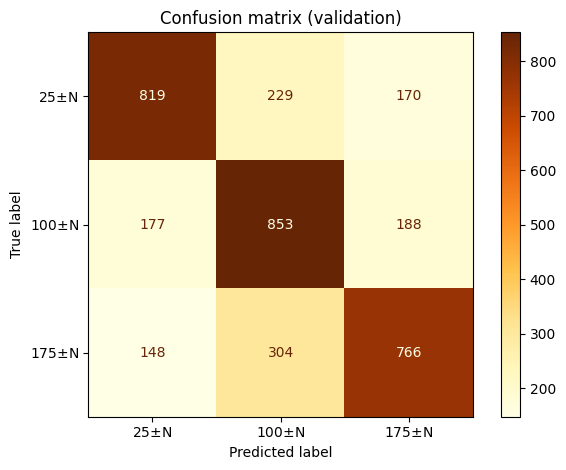

In [28]:
cm = confusion_matrix(cmy_true, cmy_pred)
print("\nClassification Report:")
print(classification_report(cmy_true, cmy_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_label)
disp.plot(cmap="YlOrBr", values_format="d")
plt.title("Confusion matrix (validation)")
plt.tight_layout()
plt.savefig("imgs/TrainValid_F_LR.pdf")  # Adjustment place
plt.show()

_Train/Test - Patient split_

In [29]:
params_path = "params/TrainTest_F_LR.pkl"  # Adjustment place

pipe = Pipeline(
    [("scaler", StandardScaler()), ("LR", LogisticRegression())]
)  # Adjustment place
cv = GroupKFold(n_splits=5)

if os.path.exists(params_path):
    print("Loaded params")
    best_params_ = joblib.load(params_path)
else:
    grid = GridSearchCV(
        pipe, param_grid, scoring="accuracy", cv=cv, n_jobs=80, verbose=1, refit=True
    )
    grid.fit(EIT, y, groups=Pwise)
    best_params_ = {k.replace("LR__", ""): v for k, v in grid.best_params_.items()}
    joblib.dump(best_params_, params_path)
    print("Best CV-Accuracy:", grid.best_score_)

print("Best parameter:", best_params_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best CV-Accuracy: 0.389287911609493
Best parameter: {'C': 10, 'class_weight': None, 'penalty': 'l1', 'solver': 'liblinear'}


In [30]:
best_model = LogisticRegression(**best_params_)  # Adjustment place

cv = GroupKFold(n_splits=5)
scores = []

cmy_pred = []
cmy_true = []
for fold, (train_idx, test_idx) in enumerate(cv.split(EIT, y, groups=Pwise), 1):
    X_train, X_test = EIT[train_idx], EIT[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)
    cmy_pred.append(y_pred)
    cmy_true.append(y_test)
    acc = balanced_accuracy_score(y_test, y_pred)
    scores.append(acc)
    print(f"Fold {fold} Accuracy: {acc:.4f}")

cmy_pred = np.concatenate(cmy_pred)
cmy_true = np.concatenate(cmy_true)

print("\nMean Accuracy:", np.mean(scores))
print("Std Accuracy:", np.std(scores))
print("\naccuracy_score", accuracy_score(cmy_true, cmy_pred))
print("balanced_accuracy_score", balanced_accuracy_score(cmy_true, cmy_pred))

Fold 1 Accuracy: 0.3012
Fold 2 Accuracy: 0.3240
Fold 3 Accuracy: 0.4052
Fold 4 Accuracy: 0.3184
Fold 5 Accuracy: 0.3903

Mean Accuracy: 0.3478189180652993
Std Accuracy: 0.04173684776517055

accuracy_score 0.35002736726874656
balanced_accuracy_score 0.35002736726874656



Classification Report:
              precision    recall  f1-score   support

         0.0       0.34      0.66      0.44      1218
         1.0       0.34      0.15      0.20      1218
         2.0       0.40      0.25      0.31      1218

    accuracy                           0.35      3654
   macro avg       0.36      0.35      0.32      3654
weighted avg       0.36      0.35      0.32      3654



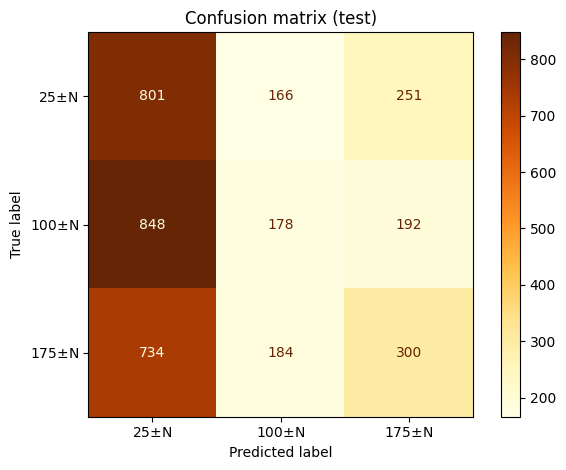

In [31]:
cm = confusion_matrix(cmy_true, cmy_pred)
print("\nClassification Report:")
print(classification_report(cmy_true, cmy_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_label)
disp.plot(cmap="YlOrBr", values_format="d")
plt.title("Confusion matrix (test)")
plt.tight_layout()
plt.savefig("imgs/TrainTest_F_LR.pdf")  # Adjustment place
plt.show()

___